# Phase 3: Layer 3 — Memory-Feasibility Proxy and the Three-Way RQ2 Split

**Project:** A Perception-Aware Framework for Evaluating Counterfactual Passing Options in Professional Football
**Author:** Raeesa Lorgat (2686242)

**Purpose of this notebook:** rerun the RQ2 forward-bias rate not just on the visible group, but across three groups: visible (inside the 120° cone), invisible-but-memory-feasible (outside the cone, but a simple position-prediction baseline still places the teammate close to their true location), and invisible-and-memory-infeasible (outside the cone, and the baseline prediction is too unreliable to count as "known").

The real RQ3 LSTM is not trained yet. This notebook uses a linear-extrapolation baseline instead, the same baseline the proposal specifies the LSTM itself needs to beat (Section 4.6), as an explicit proxy. Every result here is labelled "proxy pending trained LSTM." When the LSTM is trained, it plugs into the same three-way structure by swapping the position-prediction function; nothing else downstream changes.

This notebook loads `candidates_full` directly from the pickle saved at the end of `layer2_bias_analysis.ipynb`, rather than rebuilding the offside/xP/forward-progressive classification from scratch.

In [17]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import pickle
import glob
from pathlib import Path
import matplotlib.pyplot as plt
from mplsoccer import Pitch

from statsbombpy import sb
import statsbombpy.public as sbpublic
# route around raw.githubusercontent.com's outage via the jsDelivr mirror, same as layer2
sbpublic.OPEN_DATA_PATHS = {
    k: v.replace(
        "https://raw.githubusercontent.com/statsbomb/open-data/master",
        "https://cdn.jsdelivr.net/gh/statsbomb/open-data@master",
    )
    for k, v in sbpublic.OPEN_DATA_PATHS.items()
}

import sys
sys.path.append('..')
from src.vision_cone import add_orientation_vectors

pd.set_option('display.max_columns', None)

Load the classified candidate table and supporting models

`candidates_full` already has visibility, offside, xP, and forward-progressive status computed by Layer 2. This notebook only adds the memory-feasibility dimension on top.

In [18]:
candidates_full = pd.read_pickle('../data/results/candidates_full.pkl')
print(f"{len(candidates_full)} candidate rows loaded")
print(candidates_full.columns.tolist())

with open('../data/results/xp_model_full.pkl', 'rb') as f:
    xp_model_full = pickle.load(f)

import socceraction.xthreat as xthreat
xT_model = xthreat.load_model("https://karun.in/blog/data/open_xt_12x8_v1.json")

664518 candidate rows loaded
['match_id', 'original_event_id', 'passer_location', 'candidate_location', 'visible', 'candidate_value', 'real_end_x', 'real_end_y', 'real_value', 'cand_x', 'cand_y', 'offside', 'attacking_toward_x', 'xp_value', 'xt_origin', 'xt_target', 'forward_progressive', 'legitimate_forward_progressive']


Diagnostic : can we identify which player each candidate row is?

Linear extrapolation needs a specific player's last couple of touches before the pass, not just "some nearby teammate." 

Two things to check:
1. Does `candidates_full` (or the underlying `candidates_all3` / vision-cone table) carry a player id or name for each candidate row?
2. Does the StatsBomb 360 freeze frame itself carry a persistent player identifier for non-actor players, or only location + `teammate` + `keeper` flags?

If neither carries identity, the fallback is to match candidates to players via the main `events` dataframe: find events by teammates of the passer's team, in the same match and period, whose location at their most recent touch is closest to this candidate's freeze-frame location : an approximate match, not an exact one, and worth flagging as a limitation if used.

In [19]:
print("candidates_full columns:", candidates_full.columns.tolist())
print()

sample_match_id = candidates_full['match_id'].iloc[0]
sample_frames = sb.frames(match_id=str(sample_match_id), fmt='dataframe')
print("360 frame columns:", sample_frames.columns.tolist())
print()
print(sample_frames.head(3))
print()

sample_events = sb.events(match_id=str(sample_match_id))
print("events columns (identity-relevant):", [c for c in sample_events.columns if 'player' in c.lower() or 'id' in c.lower()])

candidates_full columns: ['match_id', 'original_event_id', 'passer_location', 'candidate_location', 'visible', 'candidate_value', 'real_end_x', 'real_end_y', 'real_value', 'cand_x', 'cand_y', 'offside', 'attacking_toward_x', 'xp_value', 'xt_origin', 'xt_target', 'forward_progressive', 'legitimate_forward_progressive']

360 frame columns: ['id', 'visible_area', 'match_id', 'teammate', 'actor', 'keeper', 'location']

                                     id  \
0  5c888f58-fe77-459b-ab3b-a2fa5fb8ab16   
1  5c888f58-fe77-459b-ab3b-a2fa5fb8ab16   
2  5c888f58-fe77-459b-ab3b-a2fa5fb8ab16   

                                        visible_area match_id  teammate  \
0  [0.0, 27.7649873094419, 19.2332231959735, 17.3...  3788741     False   
1  [0.0, 27.7649873094419, 19.2332231959735, 17.3...  3788741     False   
2  [0.0, 27.7649873094419, 19.2332231959735, 17.3...  3788741     False   

   actor  keeper                                 location  
0  False   False   [43.65321648946649, 31.98843

Diagnostic result : no player identity in candidates_full or the freeze frame

Result:

- `candidates_full` columns: `match_id`, `original_event_id`, `passer_location`, `candidate_location`, `visible`, `candidate_value`, `real_end_x`, `real_end_y`, `real_value`, `cand_x`, `cand_y`, `offside`, `attacking_toward_x`, `xp_value`, `xt_origin`, `xt_target`, `forward_progressive`, `legitimate_forward_progressive` — no player id or name.
- 360 frame columns: `id`, `visible_area`, `match_id`, `teammate`, `actor`, `keeper`, `location` — no persistent player identity for non-actor players either, by design of the freeze-frame format.
- `events` columns do carry identity: `player`, `player_id`, `team_id`.

**Conclusion:** which player a candidate row actually is can't be read directly. It has to be inferred : matching each candidate's freeze-frame location to whichever teammate's own most recent recorded touch (from `events`) sits closest to it. This is an approximation, not a certainty, and it's worth stating that plainly if asked: unlike the offside or xP corrections, which fixed genuine bugs, this identity match is inherent to what StatsBomb 360 data can support without real player tracking, and is part of why this is a proxy pending the trained LSTM rather than a finished result.

Build each player's position history, and resolve candidate identity by nearest last-known position

Two pieces:

1. `build_player_position_history` reads every event in the match with a recorded `location`, keyed by `player_id`, sorted by time — this is what both the identity match and the extrapolation read from.
2. `match_candidate_to_player` resolves identity: among teammates of the passer (same `team_id`) with a known position before this pass, pick whichever one's last known position is closest to the candidate's freeze-frame location. Ties/collisions are resolved by nearest distance, with already-matched players excluded within the same event so two candidates in the same frame don't collapse onto the same identity.

In [20]:
def build_player_position_history(m_events):
    """
    Returns {player_id: [(timestamp_seconds, (x, y), team_id), ...]}, sorted by
    time, for every event in this match where the acting player's own location
    is recorded (passes, carries, dribbles, pressures, etc.).
    """
    history = {}
    events_with_loc = m_events[m_events['location'].notna() & m_events['player_id'].notna()].copy()
    events_with_loc['timestamp_seconds'] = (
        events_with_loc['minute'] * 60 + events_with_loc['second']
    )
    events_with_loc = events_with_loc.sort_values('timestamp_seconds')

    for _, row in events_with_loc.iterrows():
        pid = row['player_id']
        history.setdefault(pid, []).append(
            (row['timestamp_seconds'], tuple(row['location']), row['team_id'])
        )
    return history


def last_known_position(history, player_id, t_target):
    """Most recent (x, y) for player_id strictly before t_target, or None."""
    if player_id not in history:
        return None
    prior = [p for p in history[player_id] if p[0] < t_target]
    return prior[-1][1] if prior else None


def recent_positions_before(history, player_id, t_target, n=2):
    """Last n (timestamp, (x, y)) pairs for player_id strictly before t_target."""
    if player_id not in history:
        return []
    prior = [(t, pos) for (t, pos, _team) in history[player_id] if t < t_target]
    return prior[-n:]


def match_candidate_to_player(history, team_id, t_target, cand_xy, exclude_ids=None):
    """
    Approximate identity resolution: among all players on `team_id` with a
    known position before t_target, return the player_id whose last known
    position is closest to the candidate's freeze-frame location, plus the
    match distance (useful for sanity-checking how confident the match is).
    """
    exclude_ids = exclude_ids or set()
    best_pid, best_dist = None, np.inf
    for pid, entries in history.items():
        if pid in exclude_ids:
            continue
        if entries[0][2] != team_id:
            continue
        pos = last_known_position(history, pid, t_target)
        if pos is None:
            continue
        dist = np.hypot(pos[0] - cand_xy[0], pos[1] - cand_xy[1])
        if dist < best_dist:
            best_dist = dist
            best_pid = pid
    return best_pid, best_dist

Linear-extrapolation position estimate and the memory-feasibility threshold

Constant-velocity extrapolation from the matched player's last two recorded touches. τ is the distance threshold below which the estimate counts as "memory-feasible" — set to 4.0m, the midpoint of the proposal's 3–5m defensive-line-width justification (Section 4.6). 

In [21]:
TAU = 4.0  # metres — midpoint of the proposal's 3-5m defensive-line-width justification


def linear_extrapolation_position(recent, t_target):
    """
    recent: [(timestamp, (x, y)), ...] — sorted ascending, up to 2 points.
    Returns predicted (x, y) at t_target via constant-velocity extrapolation,
    or the last known position if fewer than 2 points are available.
    """
    if len(recent) == 0:
        return None
    if len(recent) == 1:
        return recent[-1][1]

    (t0, (x0, y0)), (t1, (x1, y1)) = recent[-2], recent[-1]
    dt = t1 - t0
    if dt <= 0:
        return (x1, y1)

    vx, vy = (x1 - x0) / dt, (y1 - y0) / dt
    dt_forward = t_target - t1
    return (x1 + vx * dt_forward, y1 + vy * dt_forward)


def is_memory_feasible(predicted_pos, true_pos, tau=TAU):
    if predicted_pos is None:
        return False
    err = np.hypot(predicted_pos[0] - true_pos[0], predicted_pos[1] - true_pos[1])
    return err < tau

Sanity-check this against one real example before running it over all invisible candidates

In [22]:
sample_row = candidates_full[~candidates_full['visible']].iloc[0]
sample_match_id = str(sample_row['match_id'])

m_events_sample = sb.events(match_id=sample_match_id)
history_sample = build_player_position_history(m_events_sample)

m_events_indexed_sample = m_events_sample.set_index('id')
event_row = m_events_indexed_sample.loc[sample_row['original_event_id']]
t_target_sample = event_row['minute'] * 60 + event_row['second']
passer_team_id = event_row['team_id']

matched_pid, match_dist = match_candidate_to_player(
    history_sample, passer_team_id, t_target_sample,
    (sample_row['cand_x'], sample_row['cand_y'])
)
print(f"Matched player_id={matched_pid}, identity-match distance={match_dist:.2f}m")

recent_sample = recent_positions_before(history_sample, matched_pid, t_target_sample)
print(f"Recent touches before this pass: {recent_sample}")

predicted = linear_extrapolation_position(recent_sample, t_target_sample)
true_pos = (sample_row['cand_x'], sample_row['cand_y'])
if predicted is not None:
    error = np.hypot(predicted[0] - true_pos[0], predicted[1] - true_pos[1])
    print(f"predicted={predicted}, true={true_pos}, extrapolation error={error:.2f}m, memory_feasible={error < TAU}")
else:
    print("No prior touches found for this player before this event — can't extrapolate.")

Matched player_id=8963.0, identity-match distance=23.96m
Recent touches before this pass: [(2, (32.5, 28.8)), (2, (32.5, 28.8))]
predicted=(32.5, 28.8), true=(26.9336, 52.1045), extrapolation error=23.96m, memory_feasible=False


Two distances matter here and are easy to conflate: the **identity-match distance** (how far the matched player's *last known* position was from the candidate's freeze-frame location (this is the approximation cost from not having real tracking) and the **extrapolation error** (how far the *predicted* position, projected forward in time, ends up from the true location) this is what actually feeds the memory-feasibility threshold). A small identity-match distance but large extrapolation error means the identity guess was probably right but the player moved fast between their last touch and this pass.

What this specific example shows

This particular example is a weak one to showcase, and it is useful to see why. The matched player's only two recorded touches before this pass are both logged at the same timestamp, 2 seconds into the match, at the same location, since this is very early in the game and the player has almost no history yet. With dt equal to zero between those two touches, the constant-velocity formula cannot estimate a velocity at all and falls back to the last known position as its prediction. That means the extrapolation error here, 23.96m, is identical to the identity-match distance itself. The model is not really predicting movement here, it is just reusing a stale position from over 20 metres away. A later-match example, where a player has a longer touch history, would give a fairer picture of how the extrapolation performs once there is real velocity information to work with.

Classify every invisible candidate as memory-feasible or not

Runs identity matching and extrapolation across every row in `candidates_full` where `visible` is False, grouped by match and event so each match's history is only built once and matched candidates within the same event don't collide onto the same player.

In [23]:
def classify_memory_feasibility_for_match(match_candidates, mid):
    m_events = sb.events(match_id=str(mid))
    history = build_player_position_history(m_events)
    m_events_indexed = m_events.set_index('id')

    results = []
    for event_id, event_candidates in match_candidates.groupby('original_event_id'):
        if event_id not in m_events_indexed.index:
            for idx in event_candidates.index:
                results.append((idx, None, np.nan, False))
            continue

        event_row = m_events_indexed.loc[event_id]
        t_target = event_row['minute'] * 60 + event_row['second']
        team_id = event_row['team_id']

        matched_this_event = set()
        for idx, cand in event_candidates.iterrows():
            cand_xy = (cand['cand_x'], cand['cand_y'])
            matched_pid, match_dist = match_candidate_to_player(
                history, team_id, t_target, cand_xy, exclude_ids=matched_this_event
            )
            if matched_pid is None:
                results.append((idx, None, np.nan, False))
                continue
            matched_this_event.add(matched_pid)

            recent = recent_positions_before(history, matched_pid, t_target)
            predicted = linear_extrapolation_position(recent, t_target)
            feasible = is_memory_feasible(predicted, cand_xy)
            results.append((idx, matched_pid, match_dist, feasible))

    return results


invisible = candidates_full[~candidates_full['visible']].copy()
all_results = []

unique_match_ids = invisible['match_id'].unique()
for i, mid in enumerate(unique_match_ids):
    match_candidates = invisible[invisible['match_id'] == mid]
    all_results.extend(classify_memory_feasibility_for_match(match_candidates, mid))
    if (i + 1) % 20 == 0:
        print(f"[{i+1}/{len(unique_match_ids)}] matches processed")

results_df = pd.DataFrame(all_results, columns=['idx', 'matched_player_id', 'identity_match_dist', 'memory_feasible']).set_index('idx')
invisible = invisible.join(results_df)

print(invisible['memory_feasible'].value_counts(dropna=False))
print(f"Median identity-match distance: {invisible['identity_match_dist'].median():.2f}m")

[20/166] matches processed
[40/166] matches processed
[60/166] matches processed
[80/166] matches processed
[100/166] matches processed
[120/166] matches processed
[140/166] matches processed
[160/166] matches processed
memory_feasible
False    417243
True      23822
Name: count, dtype: int64
Median identity-match distance: 12.94m


Check the identity-match distance distribution before trusting the memory-feasible counts. If it's mostly large (players scattered far from any teammate's last known position), the identity resolution itself is unreliable and the memory-feasible rate below should be reported with that caveat attached, not as a clean number.

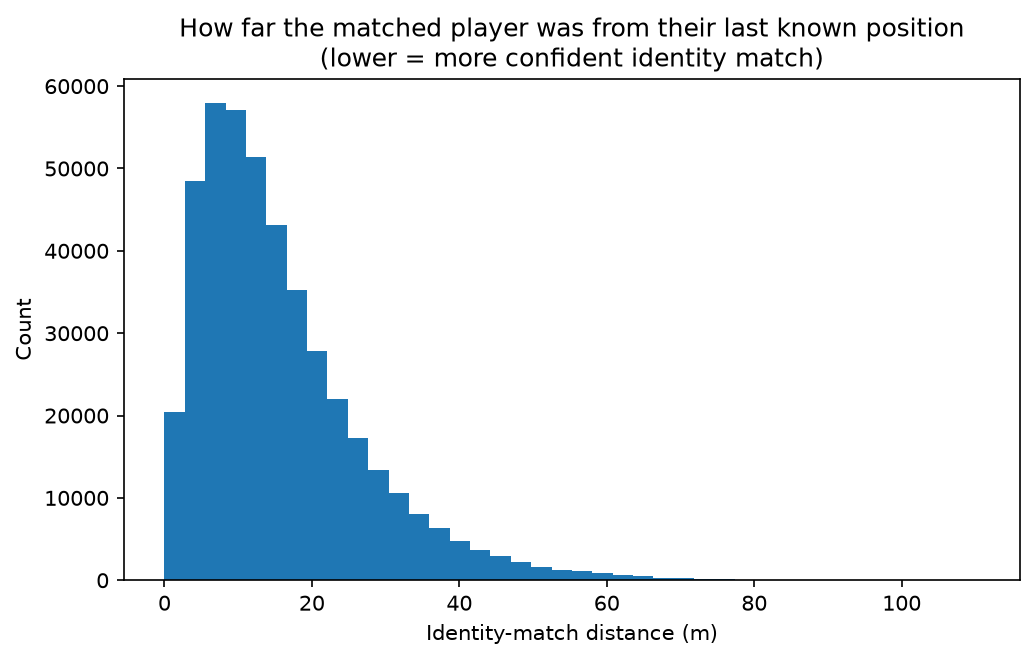

count    439712.000000
mean         15.688528
std          11.354364
min           0.003667
25%           7.497441
50%          12.938082
75%          20.858980
max         110.518099
Name: identity_match_dist, dtype: float64


In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
ax.hist(invisible['identity_match_dist'].dropna(), bins=40)
ax.set_xlabel('Identity-match distance (m)')
ax.set_ylabel('Count')
ax.set_title('How far the matched player was from their last known position\n(lower = more confident identity match)')
plt.tight_layout()
plt.show()

print(invisible['identity_match_dist'].describe())

Reading the identity-match distance distribution

The median identity-match distance across all invisible candidates is 12.94m, already well above the 4.0m threshold used to call something memory-feasible. That means for the typical invisible candidate, the nearest-teammate guess used to establish identity is not close to confident on its own, before extrapolation error is even added on top. The candidates that do end up classified as memory-feasible sit in the tail of this distribution, close to zero, a real but small group, not the norm. This is the numeric basis for treating the memory_feasible label as approximate rather than a confirmed identity match.

Rerun the RQ2 forward-bias rate across all three groups

Same `legitimate_forward_progressive` definition as Layer 2 (offside, xP ≥ 0.05, forward-progressive by xT and VAEP), just grouped by visibility/memory-feasibility instead of collapsed to a single visible-only figure. 

In [25]:
candidates_full['group'] = 'visible'
candidates_full.loc[invisible.index, 'group'] = invisible['memory_feasible'].map(
    {True: 'memory_feasible', False: 'memory_infeasible'}
)
candidates_full.loc[candidates_full['visible'], 'group'] = 'visible'

print(candidates_full['group'].value_counts())

group
memory_infeasible    417243
visible              223453
memory_feasible       23822
Name: count, dtype: int64


What the group sizes say before looking at rates

23822 of the 441065 invisible candidate rows, about 5.4 percent, cleared the 4.0m memory-feasibility threshold. The large majority of invisible candidates, roughly 94.6 percent, fall into memory_infeasible. That imbalance matters for how much weight to put on the memory_feasible rate below. It is a genuinely small, unusual subset of invisible candidates, not a representative half of them, so any pattern found in it describes that unusual subset specifically rather than invisible candidates in general.

In [26]:
candidates_full['legitimate_forward_progressive_any_vis'] = (
    (~candidates_full['offside'].fillna(True))
    & (candidates_full['xp_value'] >= 0.05)
    & candidates_full['forward_progressive']
)

from scipy.stats import binomtest

for group_name, group_df in candidates_full.groupby('group'):
    pass_level_group = group_df.groupby(['match_id', 'original_event_id']).agg(
        had_legit_forward_option=('legitimate_forward_progressive_any_vis', 'any')
    ).reset_index()
    n_total = len(pass_level_group)
    n_bypassed = int(pass_level_group['had_legit_forward_option'].sum())
    rate = n_bypassed / n_total if n_total else float('nan')
    result = binomtest(n_bypassed, n_total, p=0.5) if n_total else None
    p_str = f"{result.pvalue:.4f}" if result else "n/a"
    print(f"{group_name}: {n_bypassed}/{n_total} = {rate:.1%}  (binomial p={p_str})")

memory_feasible: 5572/21446 = 26.0%  (binomial p=0.0000)
memory_infeasible: 52970/96576 = 54.8%  (binomial p=0.0000)
visible: 44932/82045 = 54.8%  (binomial p=0.0000)


Interpreting the three-way split

The expectation going in was that memory_feasible would land somewhere between visible and memory_infeasible, since more knowledge should mean more visible-like behaviour. Instead memory_feasible is lower, 26.0 percent, than both visible and memory_infeasible, which sit close together at 54.8 percent.

The likely explanation is a bias built into the extrapolation method itself, not a real perceptual effect. Constant-velocity extrapolation assumes a player keeps moving in a straight line at a constant speed. That assumption breaks down exactly for players making dynamic forward runs, accelerating, changing direction, breaking away from a marker. So the memory_feasible label does not pick a random sample of invisible candidates, it picks out players who happened to be moving predictably, which skews toward calmer, more static positioning and away from the kind of movement that produces a genuinely forward-progressive option. If that is what is happening here, the 26.0 percent figure is showing the proxy's own blind spot for dynamic movement, not a real difference in decision-making bias.

This is compounded by the identity-match caveat from earlier. The median identity-match distance across all invisible candidates is 12.94m, well above the 4.0m memory-feasibility threshold itself, so a meaningful share of memory_feasible rows may not even be the correct player. The 26.0 percent figure should be read as noisy on top of being possibly confounded by the extrapolation method's own weakness.

One more thing worth flagging so this number is never compared directly to the RQ2 headline: the visible group here shows 54.8 percent, not the 45.5 percent reported as the main RQ2 result. That is not a contradiction. The headline 45.5 percent is bypassed passes over all 98652 qualifying passes. Here, each group's denominator is passes that had at least one candidate in that specific group, since grouping happens before the pass-level aggregation. The visible group's denominator here is 82045, a smaller base than 98652, since some qualifying passes had no visible candidate at all, so the same kind of bypassed count lands on a higher rate. Both numbers are correct, they are just answering different questions, one flat rate across everything, one rate conditional on a group having an option at all.

Bottom line: this three-way split is a genuinely useful proxy result to have built, and the pipeline structure is exactly what the trained LSTM will slot into later. But 26.0 percent should not be presented as a clean finding. The honest framing is that the constant-velocity baseline's own weakness for dynamic movement is likely driving this number down, which is itself a point in favour of why the real LSTM, capable of learning accelerating, nonlinear trajectories, is needed rather than staying on this proxy.

**Proxy pending trained LSTM, resting on an approximate identity match.** These figures use constant-velocity extrapolation as a stand-in for RQ3's actual model, per the proposal's own baseline comparison, and identity for invisible candidates is inferred by nearest-last-known-position matching rather than read from real tracking data. When the trained LSTM is ready, only `linear_extrapolation_position` step needs to be replaced with the model's prediction; the identity-matching approach step is a separate limitation of the data source itself and stays regardless of which prediction model is used.